# **AI-Based Smartphone Decision Support System**

## **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Load Dataset**

In [ ]:
# Download the smartphone dataset from Kaggle

import kagglehub
path = kagglehub.dataset_download("githubmasterin/smartphones-cleaned-dataset")
print(path)

100%|██████████| 16.8k/16.8k [00:00<00:00, 22.0MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/githubmasterin/smartphones-cleaned-dataset/versions/1


In [ ]:
import os
print(os.listdir(path))

['smartphones.csv']


In [ ]:
filename = 'smartphones.csv'
full_file_name = os.path.join(path, filename)

df = pd.read_csv(full_file_name)
df.head()

,smartphone_brand,model,price_inr,rating_score,processor_name,processor_brand,core_count,clock_speed_ghz,ram_gb,storage_gb,...,battery_mah,fast_charging,charging_watt,rear_camera_count,front_camera_count,rear_camera_main_mp,front_camera_main_mp,os_name,memory_card_supported,memory_card_type
0,blackzone,BlackZone S25 Ultra Maxx,8999,63,unisoc sc9863a1,unisoc,8,1.6,8,128,...,5000,False,10.0,1,1,32.0,16.0,android,NaN,NaN
1,ringme,Ringme Bold P70,5800,44,mediatek helio,mediatek,2,1.3,4,128,...,3260,False,10.0,1,0,13.0,NaN,android,NaN,NaN
2,lava,Lava Shark 5G (4GB RAM + 128GB),8998,60,unisoc t765,unisoc,8,2.3,4,128,...,5000,True,10.0,1,1,13.0,5.0,android,True,dedicated
3,vivo,Vivo Y19s 5G (4GB RAM + 128GB),11999,69,mediatek dimensity 6300,mediatek,8,2.4,4,128,...,6000,True,15.0,2,1,13.0,5.0,android,True,dedicated
4,vivo,Vivo Y19s 5G (4GB RAM + 64GB),10999,68,mediatek dimensity 6300,mediatek,8,2.4,4,64,...,6000,True,15.0,2,1,13.0,5.0,android,True,dedicated


## EDA

In [ ]:
print("Number of rows and column:",df.shape)

Number of rows and column: (758, 27)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   smartphone_brand       758 non-null    object 
 1   model                  758 non-null    object 
 2   price_inr              758 non-null    int64  
 3   rating_score           758 non-null    int64  
 4   processor_name         758 non-null    object 
 5   processor_brand        758 non-null    object 
 6   core_count             758 non-null    int64  
 7   clock_speed_ghz        758 non-null    float64
 8   ram_gb                 758 non-null    int64  
 9   storage_gb             758 non-null    int64  
 10  has_5g                 758 non-null    bool   
 11  has_nfc                758 non-null    bool   
 12  has_ir_blaster         758 non-null    bool   
 13  display_inches         758 non-null    float64
 14  res_width_px           758 non-null    int64  
 15  res_he

In [ ]:
df.describe()

,price_inr,rating_score,core_count,clock_speed_ghz,ram_gb,storage_gb,display_inches,res_width_px,res_height_px,refresh_rate_hz,battery_mah,charging_watt,rear_camera_count,front_camera_count,rear_camera_main_mp,front_camera_main_mp
count,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,758.000000,753.000000
mean,29424.088391,78.587071,7.906332,2.597889,7.990765,220.496042,6.697810,1043.919525,2234.897098,114.182058,5373.569921,45.982850,2.110818,1.015831,52.234828,19.446879
std,32989.687389,8.372894,0.701338,0.596162,3.134361,168.366358,0.285648,260.683929,494.157749,18.061720,980.222628,28.744416,0.707285,0.169738,26.662235,14.483133
min,4040.000000,37.000000,1.000000,1.000000,2.000000,32.000000,3.750000,128.000000,160.000000,60.000000,2000.000000,5.000000,1.000000,0.000000,8.000000,5.000000
25%,11857.250000,74.000000,8.000000,2.300000,6.000000,128.000000,6.670000,720.000000,1612.000000,120.000000,5000.000000,25.000000,2.000000,1.000000,50.000000,8.000000
50%,18999.000000,80.000000,8.000000,2.400000,8.000000,128.000000,6.700000,1080.000000,2400.000000,120.000000,5000.000000,44.000000,2.000000,1.000000,50.000000,13.000000
75%,29990.000000,84.000000,8.000000,2.800000,8.000000,256.000000,6.770000,1206.000000,2532.000000,120.000000,6000.000000,68.000000,3.000000,1.000000,50.000000,32.000000
max,229900.000000,97.000000,10.000000,4.470000,24.000000,2048.000000,8.030000,2400.000000,3168.000000,165.000000,21200.000000,125.000000,3.000000,2.000000,200.000000,50.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
smartphone_brand,0
model,0
price_inr,0
rating_score,0
processor_name,0
processor_brand,0
core_count,0
clock_speed_ghz,0
ram_gb,0
storage_gb,0


In [ ]:
print(df.dtypes)

smartphone_brand          object
model                     object
price_inr                  int64
rating_score               int64
processor_name            object
processor_brand           object
core_count                 int64
clock_speed_ghz          float64
ram_gb                     int64
storage_gb                 int64
has_5g                      bool
has_nfc                     bool
has_ir_blaster              bool
display_inches           float64
res_width_px               int64
res_height_px              int64
refresh_rate_hz            int64
battery_mah                int64
fast_charging               bool
charging_watt            float64
rear_camera_count          int64
front_camera_count         int64
rear_camera_main_mp      float64
front_camera_main_mp     float64
os_name                   object
memory_card_supported     object
memory_card_type          object
dtype: object


In [ ]:
df["smartphone_brand"].value_counts()

,count
smartphone_brand,
realme,134
samsung,104
vivo,94
oppo,67
xiaomi,41
motorola,40
lava,40
poco,31
tecno,31


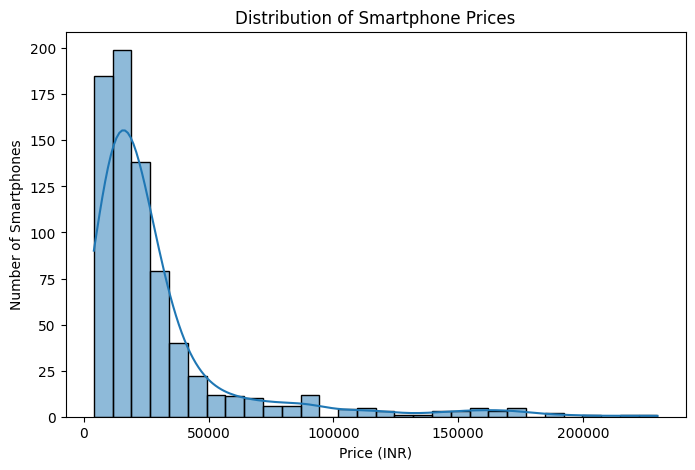

In [ ]:
# Plot the distribution of smartphone prices
plt.figure(figsize=(8, 5))

sns.histplot(df["price_inr"], bins=30, kde=True)

plt.title("Distribution of Smartphone Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Smartphones")
plt.show()

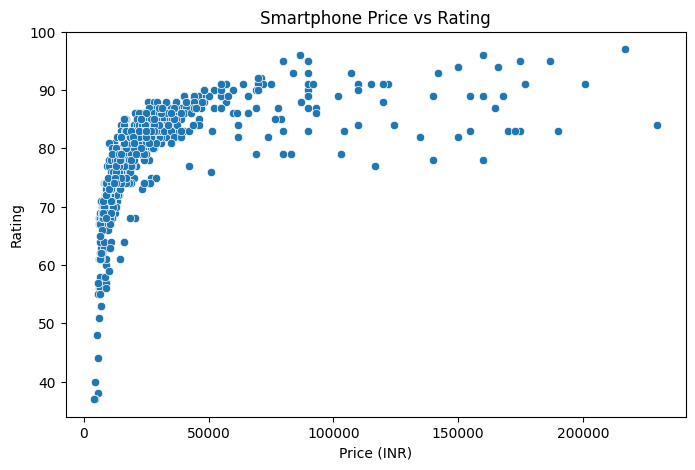

In [ ]:
# Create a scatter plot between price and rating
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df,x="price_inr",y="rating_score")

plt.title("Smartphone Price vs Rating")
plt.xlabel("Price (INR)")
plt.ylabel("Rating")
plt.show()

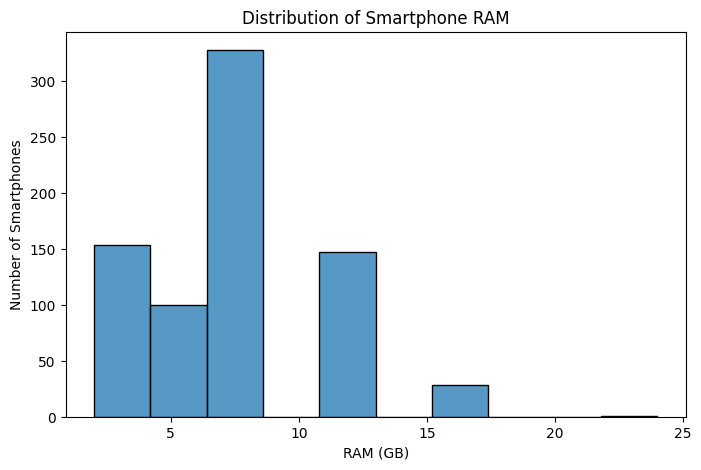

In [ ]:
# Plot the distribution of RAM
plt.figure(figsize=(8, 5))
sns.histplot(df["ram_gb"], bins=10)

plt.title("Distribution of Smartphone RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Number of Smartphones")
plt.show()

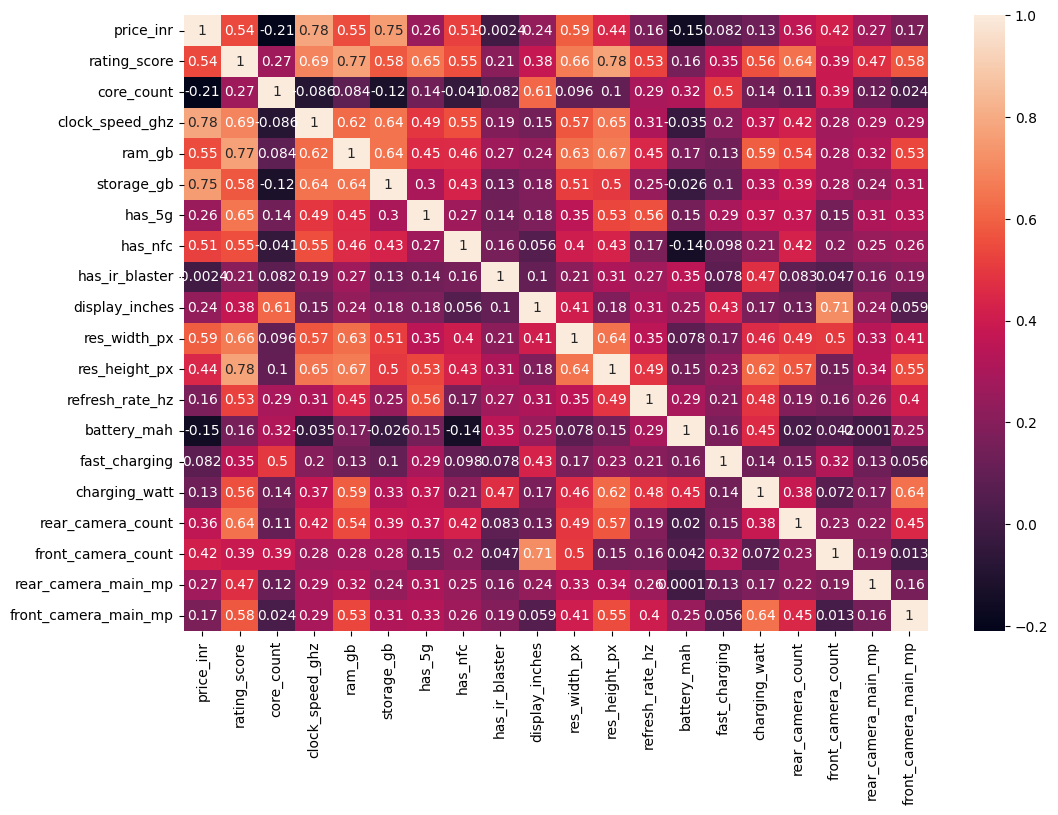

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Data Preprocessing

In [ ]:
# Fill missing front camera values with the mean of the column

df["front_camera_main_mp"] = df["front_camera_main_mp"].fillna(df["front_camera_main_mp"].mean())

In [ ]:
# Drop columns that are not required for the model

df.drop(columns=["memory_card_supported", "memory_card_type"], inplace=True)

In [ ]:
def phone_category(price):
    if price < 20000:
        return "Budget"
    elif price <= 40000:
        return "Mid-Range"
    else:
        return "Premium"

df["phone_category"] = df["price_inr"].apply(phone_category)

In [ ]:
phones_original = df.copy()

In [ ]:
# Display the unique categories in selected categorical columns

print(df["smartphone_brand"].unique(), "\n")
print(df["os_name"].unique(), "\n")
print(df["processor_brand"].unique(), "\n")
print(df["processor_name"].unique(), "\n")
print(df["phone_category"].unique(), "\n")

['blackzone' 'ringme' 'lava' 'vivo' 'nothing' 'motorola' 'peace' 'ulefone'
 'samsung' 'itel' 'realme' 'oppo' 'poco' 'tecno' 'hmd' 'apple' 'xiaomi'
 'infinix' 'iqoo' 'oneplus' 'ai+' 'alcatel' 'acer' 'cmf' 'honor' 'google'] 

['android' 'ios'] 

['unisoc' 'mediatek' 'snapdragon' 'exynos' 'apple' 'tensor'] 

['unisoc sc9863a1' 'mediatek helio' 'unisoc t765'
 'mediatek dimensity 6300' 'mediatek dimensity 7300 pro'
 'snapdragon 7s gen2' 'mediatek dimensity 7400' 'unisoc t2750'
 'exynos 1330' 'unisoc t7100' 'mediatek dimensity 7360 turbo'
 'unisoc t760' 'mediatek helio g81' 'snapdragon 7 gen4'
 'mediatek dimensity 8350' 'snapdragon 6s gen3' 'mediatek helio g99'
 'mediatek dimensity 7300 ultimate' 'unisoc 98663a'
 'mediatek dimensity 7300' 'apple a19 pro' 'apple a19'
 'mediatek dimensity 7300 energy' 'snapdragon 7 gen3' 'exynos 1380'
 'exynos 2400' 'snapdragon 8 gen3' 'mediatek dimensity 6400'
 'mediatek dimensity 7400x' 'mediatek dimensity 6400 max'
 'mediatek dimensity 7400 ultra' 'snapdrag

## Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["os_name"] = le.fit_transform(df["os_name"])
df["phone_category"] = le.fit_transform(df["phone_category"])

In [ ]:
# Apply one-hot encoding to nominal categorical features

df = pd.get_dummies(df,columns=["smartphone_brand", "processor_brand"],drop_first=True,dtype=int)

In [ ]:
binary_cols = ["has_5g", "has_nfc", "has_ir_blaster"]

df[binary_cols] = df[binary_cols].astype(int)

In [ ]:
# Drop high-cardinality columns to reduce unnecessary complexity in the model

df.drop(columns=["processor_name", "model"], inplace=True)

In [ ]:
df.columns

Index(['price_inr', 'rating_score', 'core_count', 'clock_speed_ghz', 'ram_gb',
       'storage_gb', 'has_5g', 'has_nfc', 'has_ir_blaster', 'display_inches',
       'res_width_px', 'res_height_px', 'refresh_rate_hz', 'battery_mah',
       'fast_charging', 'charging_watt', 'rear_camera_count',
       'front_camera_count', 'rear_camera_main_mp', 'front_camera_main_mp',
       'os_name', 'phone_category', 'smartphone_brand_ai+',
       'smartphone_brand_alcatel', 'smartphone_brand_apple',
       'smartphone_brand_blackzone', 'smartphone_brand_cmf',
       'smartphone_brand_google', 'smartphone_brand_hmd',
       'smartphone_brand_honor', 'smartphone_brand_infinix',
       'smartphone_brand_iqoo', 'smartphone_brand_itel',
       'smartphone_brand_lava', 'smartphone_brand_motorola',
       'smartphone_brand_nothing', 'smartphone_brand_oneplus',
       'smartphone_brand_oppo', 'smartphone_brand_peace',
       'smartphone_brand_poco', 'smartphone_brand_realme',
       'smartphone_brand_ringme'

In [ ]:
df.sample(10)

,price_inr,rating_score,core_count,clock_speed_ghz,ram_gb,storage_gb,has_5g,has_nfc,has_ir_blaster,display_inches,...,smartphone_brand_samsung,smartphone_brand_tecno,smartphone_brand_ulefone,smartphone_brand_vivo,smartphone_brand_xiaomi,processor_brand_exynos,processor_brand_mediatek,processor_brand_snapdragon,processor_brand_tensor,processor_brand_unisoc
421,29990,82,8,2.63,8,256,1,0,0,6.77,...,0,0,0,0,0,0,0,1,0,0
416,7299,62,8,1.80,4,64,0,0,1,6.67,...,0,1,0,0,0,0,0,0,0,1
330,16999,77,8,2.50,6,128,1,0,0,6.67,...,0,0,0,0,0,0,1,0,0,0
624,24990,81,8,2.20,8,256,1,0,1,6.78,...,0,1,0,0,0,0,1,0,0,0
158,56999,88,8,4.32,12,512,1,1,1,6.32,...,0,0,0,0,0,0,0,1,0,0
570,16999,79,8,2.20,8,256,1,0,0,6.70,...,0,0,0,0,0,0,0,1,0,0
248,68999,87,8,4.47,12,128,1,1,0,6.20,...,1,0,0,0,0,0,0,1,0,0
348,17998,74,8,2.40,8,128,1,0,0,6.67,...,0,0,0,0,0,0,1,0,0,0
626,7999,69,8,2.00,4,64,1,0,0,6.88,...,0,0,0,0,1,0,0,1,0,0
77,20499,81,8,2.40,8,128,1,1,0,6.70,...,1,0,0,0,0,1,0,0,0,0


## Feature selection

In [ ]:
# Separate input features from the target variable
# Regression
x_reg = df.drop(["price_inr", "phone_category"], axis=1)
y_reg = df["price_inr"]

# Classification
x_cls = df.drop(["price_inr", "phone_category"], axis=1)
y_cls = df["phone_category"]

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

x_train_cls, x_test_cls, y_train_cls, y_test_cls = train_test_split(x_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_reg = scaler.fit_transform(x_train_reg)
x_test_reg = scaler.transform(x_test_reg)

x_train_cls = scaler.fit_transform(x_train_cls)
x_test_cls = scaler.transform(x_test_cls)

## Linear Regression Model Training

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(x_train_reg, y_train_reg)

y_pred_lr = lr.predict(x_test_reg)

## Regression Model Evaluation

In [ ]:
print("MAE :", mean_absolute_error(y_test_reg, y_pred_lr))
print("MSE :", mean_squared_error(y_test_reg, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)))
print("R2 Score:", r2_score(y_test_reg, y_pred_lr))

MAE : 6124.045961282147
MSE : 88162269.09076123
RMSE: 9389.476507812415
R2 Score: 0.8590160970636705


## Logistic Regression Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logreg = LogisticRegression(max_iter=1000, random_state=42)

logreg.fit(x_train_cls, y_train_cls)

y_pred_log = logreg.predict(x_test_cls)

## Classification Model Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test_cls, y_pred_log))
print(classification_report(y_test_cls, y_pred_log))
print(confusion_matrix(y_test_cls, y_pred_log))

Accuracy: 0.9078947368421053
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        82
           1       0.85      0.85      0.85        46
           2       0.82      0.96      0.88        24

    accuracy                           0.91       152
   macro avg       0.88      0.91      0.89       152
weighted avg       0.91      0.91      0.91       152

[[76  6  0]
 [ 2 39  5]
 [ 0  1 23]]


### Confusion Matrix Interpretation

The confusion matrix shows the correct and incorrect predictions made by the classification model.

- Budget: 76 samples were correctly classified.
- Mid-Range: 39 samples were correctly classified.
- Premium: 23 samples were correctly classified.

Most values are concentrated along the diagonal, indicating that the model performs well in distinguishing the three price categories.

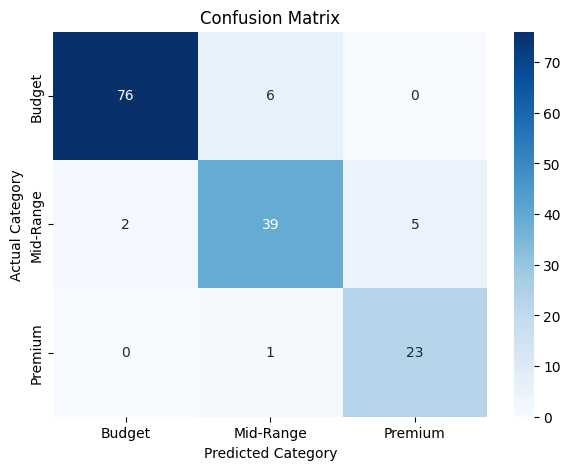

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test_cls, y_pred_log)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Define minimum hardware requirements based on the user's gaming priority

def gaming_priority(priority):
    if priority == "Low":
        return {
            "refresh_rate_hz": 60,
            "clock_speed_ghz": 2.0,
            "core_count": 6
        }

    elif priority == "Medium":
        return {
            "refresh_rate_hz": 90,
            "clock_speed_ghz": 2.4,
            "core_count": 8
        }

    else:
        return {
            "refresh_rate_hz": 120,
            "clock_speed_ghz": 3.2,
            "core_count": 8
        }

In [ ]:

# Set minimum camera specifications based on the user's camera priority

def camera_priority(level):
    if level == "High":
        return {"rear_camera_main_mp": 64, "front_camera_main_mp": 16}
    elif level == "Medium":
        return {"rear_camera_main_mp": 50, "front_camera_main_mp": 8}
    else:
        return {"rear_camera_main_mp": 12, "front_camera_main_mp": 5}

In [ ]:



# Set minimum battery specifications based on the user's battery priority

def battery_priority(priority):
    if priority == "Low":
        return {
            "battery_mah": 4500,
            "charging_watt": 25
        }

    elif priority == "Medium":
        return {
            "battery_mah": 5000,
            "charging_watt": 45
        }

    else:
        return {
            "battery_mah": 6000,
            "charging_watt": 80
        }

## User Input

In [ ]:
budget = int(input("Enter Budget (₹): "))
ram = int(input("Minimum RAM (GB): "))
storage = int(input("Minimum Storage (GB): "))

gaming_choice = input("Gaming Priority (Low/Medium/High): ")
camera_choice = input("Camera Priority (Low/Medium/High): ")
battery_choice = input("Battery Priority (Low/Medium/High): ")

gaming = gaming_priority(gaming_choice)
camera = camera_priority(camera_choice)
battery = battery_priority(battery_choice)

Enter Budget (₹): 40000
Minimum RAM (GB): 8
Minimum Storage (GB): 256
Gaming Priority (Low/Medium/High): Medium
Camera Priority (Low/Medium/High): Medium
Battery Priority (Low/Medium/High): High


In [ ]:
# Combine all user preferences into a single dictionary for recommendation
user_data = {
    "price_inr": budget,
    "ram_gb": ram,
    "storage_gb": storage,
    **gaming,
    **camera,
    **battery}

In [ ]:
# Filter smartphones based on the user's budget and minimum requirements

recommended = df[
    (df["price_inr"] <= user_data["price_inr"] + 3000) &
    (df["price_inr"] >= user_data["price_inr"] - 3000) &
    (df["ram_gb"] >= user_data["ram_gb"]) &
    (df["storage_gb"] >= user_data["storage_gb"]) &
    (df["refresh_rate_hz"] >= user_data["refresh_rate_hz"]) &
    (df["clock_speed_ghz"] >= user_data["clock_speed_ghz"]) &
    (df["core_count"] >= user_data["core_count"]) &
    (df["battery_mah"] >= user_data["battery_mah"]) &
    (df["charging_watt"] >= user_data["charging_watt"]) &
    (df["rear_camera_main_mp"] >= user_data["rear_camera_main_mp"]) &
    (df["front_camera_main_mp"] >= user_data["front_camera_main_mp"])
]

recommended = recommended.sort_values(
    by="rating_score",
    ascending=False)

# Retrieve the original smartphone details using the matching row indices
recommended = phones_original.loc[recommended.index]

print("                                                                   TOP 5 RECOMMENDED SMARTPHONES")
print("=" * 167)

# Select the important details and display
top_5 = recommended[[
        "model",
        "price_inr",
        "rating_score",
        "ram_gb",
        "storage_gb",
        "refresh_rate_hz",
        "battery_mah",
        "charging_watt",
        "rear_camera_main_mp",
        "front_camera_main_mp"
    ]].head(5)

display(top_5)

                                                                   TOP 5 RECOMMENDED SMARTPHONES


,model,price_inr,rating_score,ram_gb,storage_gb,refresh_rate_hz,battery_mah,charging_watt,rear_camera_main_mp,front_camera_main_mp
169,Realme GT 7 (12GB RAM + 256GB),39998,89,12,256,120,7000,120.0,50.0,32.0
134,Motorola Edge 60 Pro (16GB RAM + 512GB),39999,89,16,512,120,6000,90.0,50.0,50.0
84,Vivo V60 5G (8GB RAM + 256GB),38999,87,8,256,120,6500,90.0,50.0,50.0
101,Realme 15 Pro 5G (12GB RAM + 512GB),38999,87,12,512,144,7000,80.0,50.0,50.0
27,Oppo Reno 14 5G Diwali Edition,39999,87,8,256,120,6000,80.0,50.0,50.0
